# JurisData Analytics: Fase 3: Clustering de Decisões Trabalhistas

**Objetivo:** Identificar perfis de litígio por agrupamento não supervisionado
**Input:** ml.features_decisao (40.154 registros)
**Output:** cluster_id + cluster_label persistidos no PostgreSQL + visualização 2D

In [3]:
#Célula 1: Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import psycopg2
from dotenv import load_dotenv

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

load_dotenv()

PG_CONFIG = {
    "host":     os.getenv("PG_HOST", "localhost"),
    "port":     int(os.getenv("PG_PORT", "5432")),
    "dbname":   os.getenv("PG_DBNAME", "jurisdata"),
    "user":     os.getenv("PG_USER", "postgres"),
    "password": os.getenv("PG_PASSWORD", ""),
}

def get_conn():
    return psycopg2.connect(**PG_CONFIG)

print("Imports OK")

Imports OK


In [4]:
#Célula 2:  Carrega a feature store
SQL = """
SELECT
    f.process_id,
    f.tempo_tramitacao_dias,
    f.ano_ajuizamento,
    f.mes_ajuizamento,
    f.assunto_codigo,
    f.grau_encoded,
    f.formato_encoded,
    a.assunto_nome
FROM ml.features_decisao f
LEFT JOIN analytics.dim_assunto a ON a.assunto_codigo = f.assunto_codigo
WHERE f.tempo_tramitacao_dias IS NOT NULL
  AND f.assunto_codigo IS NOT NULL
"""

with get_conn() as conn:
    df = pd.read_sql(SQL, conn)

print("Shape:", df.shape)
print("\nPrimeiras linhas:")
print(df.head())
print("\nNulos por coluna:")
print(df.isnull().sum())

C:\Users\fabri\AppData\Local\Temp\ipykernel_3464\558140750.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(SQL, conn)


Shape: (40154, 8)

Primeiras linhas:
                      process_id  tempo_tramitacao_dias  ano_ajuizamento  \
0  TRT21_G1_00011599820245210010                    217             2024   
1  TRT21_G1_00011877520245210007                    308             2024   
2  TRT21_G1_00011584020245210002                    402             2024   
3  TRT21_G1_00011609520245210006                    472             2024   
4  TRT21_G1_00011618020245210006                    472             2024   

   mes_ajuizamento  assunto_codigo  grau_encoded  formato_encoded  \
0               12           13875             0                1   
1               12           14010             0                1   
2               12           13968             0                1   
3               12           14000             0                1   
4               12           13017             0                1   

                  assunto_nome  
0   Adicional de Insalubridade  
1   Indenização por Dano 

In [5]:
#Célula 3: Aplicando Frequency Encoding no assunto
#Calcula a frequência relativa de cada assunto
freq = df["assunto_codigo"].value_counts(normalize=True)
df["assunto_freq"] = df["assunto_codigo"].map(freq)

print("Frequency encoding aplicado.")
print(f"Exemplo — assunto 13875 (Insalubridade): {freq.get(13875, 0):.4f}")
print(f"\nDistribuição do assunto_freq:")
print(df["assunto_freq"].describe().round(4))

Frequency encoding aplicado.
Exemplo — assunto 13875 (Insalubridade): 0.0488

Distribuição do assunto_freq:
count    40154.0000
mean         0.0334
std          0.0384
min          0.0000
25%          0.0049
50%          0.0171
75%          0.0488
max          0.1234
Name: assunto_freq, dtype: float64


In [8]:
#Célula 4: Montando a matriz de features e normalizando
FEATURES = [
    "tempo_tramitacao_dias",
    "ano_ajuizamento",
    "mes_ajuizamento",
    "assunto_freq",
    "grau_encoded",
]

X = df[FEATURES].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features:", FEATURES)
print("Shape da matriz normalizada:", X_scaled.shape)
print("Média após scaling:", X_scaled.mean(axis=0).round(3))
print("Desvio após scaling:", X_scaled.std(axis=0).round(3))

Features: ['tempo_tramitacao_dias', 'ano_ajuizamento', 'mes_ajuizamento', 'assunto_freq', 'grau_encoded']
Shape da matriz normalizada: (40154, 5)
Média após scaling: [ 0.  0. -0.  0.  0.]
Desvio após scaling: [1. 1. 1. 1. 1.]


Variância explicada por componente:
  PC1: 0.399 (39.9%)
  PC2: 0.211 (21.1%)
  Total: 0.610 (61.0%)


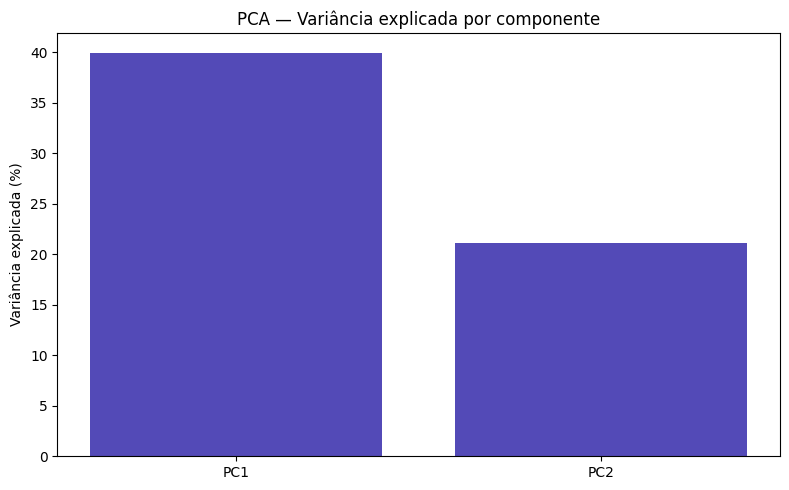

In [9]:
#Célula 5: Redução de dimensionalidade com PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Variância explicada por componente:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.3f} ({var*100:.1f}%)")
print(f"  Total: {pca.explained_variance_ratio_.sum():.3f} ({pca.explained_variance_ratio_.sum()*100:.1f}%)")

plt.figure(figsize=(8, 5))
plt.bar(["PC1", "PC2"], pca.explained_variance_ratio_ * 100, color="#534AB7")
plt.ylabel("Variância explicada (%)")
plt.title("PCA — Variância explicada por componente")
plt.tight_layout()
plt.show()

k=2 — inércia: 141030
k=3 — inércia: 100902
k=4 — inércia: 76430
k=5 — inércia: 61593
k=6 — inércia: 49852
k=7 — inércia: 43860
k=8 — inércia: 37663
k=9 — inércia: 33120
k=10 — inércia: 30536


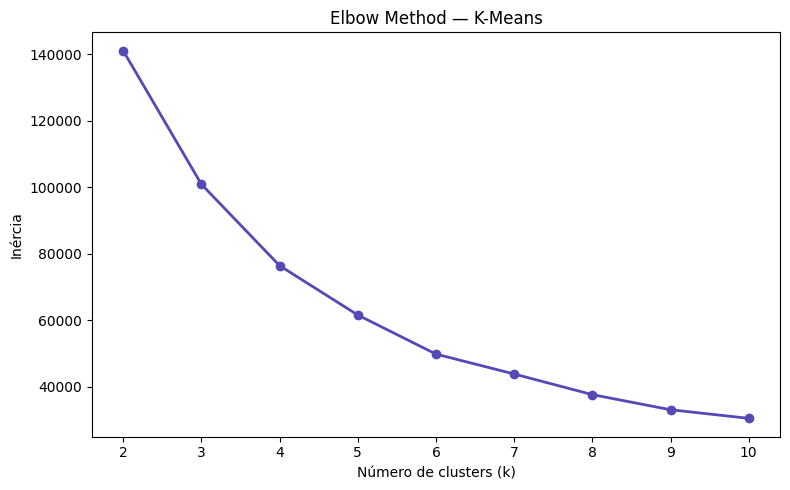

In [10]:
#Célula 6: Elbow Method para escolher k do K-Means
inercias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)
    print(f"k={k} — inércia: {km.inertia_:.0f}")

plt.figure(figsize=(8, 5))
plt.plot(K_range, inercias, marker="o", color="#534AB7", linewidth=2)
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia")
plt.title("Elbow Method — K-Means")
plt.xticks(K_range)
plt.tight_layout()
plt.show()

In [11]:
#Célula 7: Teste de Silhouette e DB para K-Means
resultados = []

for k in [3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    db  = davies_bouldin_score(X_scaled, labels)
    resultados.append({"k": k, "silhouette": sil, "davies_bouldin": db})
    print(f"k={k} — Silhouette: {sil:.3f} | Davies-Bouldin: {db:.3f}")

print("\nReferência: Silhouette maior = melhor | Davies-Bouldin menor = melhor")

k=3 — Silhouette: 0.339 | Davies-Bouldin: 0.836
k=4 — Silhouette: 0.374 | Davies-Bouldin: 0.782
k=5 — Silhouette: 0.331 | Davies-Bouldin: 0.802

Referência: Silhouette maior = melhor | Davies-Bouldin menor = melhor


In [14]:
#Célula 8: Treinando o K-Means final com K=3
#Identificado que com K=3 ficou mais bem dividido que K=4, com 2 grupos de outliers.
K_FINAL = 3

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df["cluster_kmeans"] = km_final.fit_predict(X_scaled)

print("Distribuição dos clusters:")
print(df["cluster_kmeans"].value_counts().sort_index())

print("\nPerfil por cluster:")
print(df.groupby("cluster_kmeans")[["tempo_tramitacao_dias", "ano_ajuizamento", "assunto_freq"]].mean().round(2))

print("\nTop 3 assuntos por cluster:")
for c in range(K_FINAL):
    top = df[df["cluster_kmeans"] == c]["assunto_nome"].value_counts().head(3)
    print(f"\nCluster {c} ({len(df[df['cluster_kmeans']==c])} registros):")
    print(top.to_string())

Distribuição dos clusters:
cluster_kmeans
0    18934
1    21181
2       39
Name: count, dtype: int64

Perfil por cluster:
                tempo_tramitacao_dias  ano_ajuizamento  assunto_freq
cluster_kmeans                                                      
0                             2137.68          2019.84          0.03
1                              944.19          2023.11          0.04
2                             1334.03          2021.97          0.02

Top 3 assuntos por cluster:

Cluster 0 (18934 registros):
assunto_nome
Aviso Prévio                 1912
Verbas Rescisórias           1778
Adicional de Horas Extras    1087

Cluster 1 (21181 registros):
assunto_nome
Verbas Rescisórias            3218
Rescisão Indireta             1632
Adicional de Insalubridade    1259

Cluster 2 (39 registros):
assunto_nome
Citação               3
Rescisão Indireta     2
Verbas Rescisórias    2


In [15]:
#Célula 9: Hierárquico Aglomerativo pro k=3
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3, linkage="ward")
df["cluster_hc"] = hc.fit_predict(X_scaled)

sil_hc = silhouette_score(X_scaled, df["cluster_hc"])
db_hc  = davies_bouldin_score(X_scaled, df["cluster_hc"])

sil_km = silhouette_score(X_scaled, df["cluster_kmeans"])
db_km  = davies_bouldin_score(X_scaled, df["cluster_kmeans"])

print("Comparação K-Means vs Hierárquico (k=3):")
print(f"{'Modelo':<20} {'Silhouette':>12} {'Davies-Bouldin':>15}")
print("-" * 50)
print(f"{'K-Means':<20} {sil_km:>12.3f} {db_km:>15.3f}")
print(f"{'Hierárquico':<20} {sil_hc:>12.3f} {db_hc:>15.3f}")

print("\nDistribuição Hierárquico:")
print(df["cluster_hc"].value_counts().sort_index())

Comparação K-Means vs Hierárquico (k=3):
Modelo                 Silhouette  Davies-Bouldin
--------------------------------------------------
K-Means                     0.339           0.836
Hierárquico                 0.302           0.926

Distribuição Hierárquico:
cluster_hc
0    21778
1    18337
2       39
Name: count, dtype: int64


In [16]:
#Célula 10: Nomeação dos clusters
LABELS = {
    0: "Litígios Antigos — Alta Complexidade",
    1: "Litígios Recentes — Tramitação Ágil",
    2: "Casos Atípicos",
}

df["cluster_label"] = df["cluster_kmeans"].map(LABELS)

print("Distribuição final com labels:")
print(df.groupby(["cluster_kmeans", "cluster_label"]).size().reset_index(name="total").to_string(index=False))

Distribuição final com labels:
 cluster_kmeans                        cluster_label  total
              0 Litígios Antigos — Alta Complexidade  18934
              1  Litígios Recentes — Tramitação Ágil  21181
              2                       Casos Atípicos     39


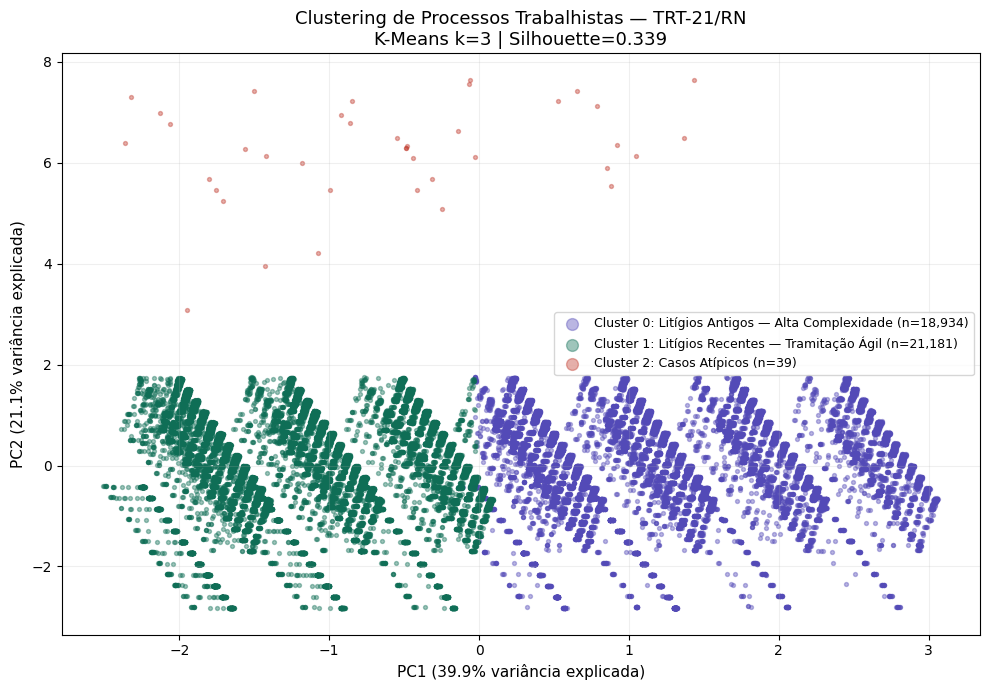

Figura salva em outputs/figures/clusters_pca_2d.png


In [18]:
#Célula 11: Visualização 2D dos clusters
CORES = {
    0: "#534AB7",
    1: "#0F6E56",
    2: "#C0392B",
}

plt.style.use("default")
fig, ax = plt.subplots(figsize=(10, 7))

for cluster_id, label in LABELS.items():
    mask = df["cluster_kmeans"] == cluster_id
    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=CORES[cluster_id],
        label=f"Cluster {cluster_id}: {label} (n={mask.sum():,})",
        alpha=0.4,
        s=8,
    )

ax.set_xlabel("PC1 (39.9% variância explicada)", fontsize=11)
ax.set_ylabel("PC2 (21.1% variância explicada)", fontsize=11)
ax.set_title("Clustering de Processos Trabalhistas — TRT-21/RN\nK-Means k=3 | Silhouette=0.339", fontsize=13)
ax.legend(fontsize=9, markerscale=3)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("../outputs/figures/clusters_pca_2d.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figura salva em outputs/figures/clusters_pca_2d.png")

In [21]:
#Célula 12: Salvando os clusters no banco
from psycopg2.extras import execute_values

rows = [
    (
        int(df.loc[i, "cluster_kmeans"]),
        df.loc[i, "cluster_label"],
        float(X_pca[i, 0]),
        float(X_pca[i, 1]),
        df.loc[i, "process_id"],
    )
    for i in range(len(df))
]

SQL_UPDATE = """
    UPDATE ml.features_decisao SET
        cluster_id    = data.cluster_id,
        cluster_label = data.cluster_label,
        embedding_x   = data.embedding_x,
        embedding_y   = data.embedding_y
    FROM (VALUES %s) AS data(cluster_id, cluster_label, embedding_x, embedding_y, process_id)
    WHERE ml.features_decisao.process_id = data.process_id
"""

with get_conn() as conn:
    with conn.cursor() as cur:
        # Cria tabela temporária tipada
        cur.execute("""
            CREATE TEMP TABLE tmp_clusters (
                process_id    TEXT,
                cluster_id    INTEGER,
                cluster_label TEXT,
                embedding_x   NUMERIC,
                embedding_y   NUMERIC
            )
        """)

        # Insere os dados na temp
        execute_values(cur, """
        INSERT INTO tmp_clusters (cluster_id, cluster_label, embedding_x, embedding_y, process_id)
        VALUES %s
        """, rows, page_size=1000)

        # Update via join com a temp
        cur.execute("""
            UPDATE ml.features_decisao f
            SET
                cluster_id    = t.cluster_id,
                cluster_label = t.cluster_label,
                embedding_x   = t.embedding_x,
                embedding_y   = t.embedding_y
            FROM tmp_clusters t
            WHERE f.process_id = t.process_id
        """)

        print(f"Registros atualizados: {cur.rowcount:,}")
    conn.commit()

Registros atualizados: 40,154


In [22]:
#Célula 13: validação final
with get_conn() as conn:
    print("Distribuição dos clusters no banco:")
    print(pd.read_sql("""
        SELECT cluster_id, cluster_label, COUNT(*) AS total
        FROM ml.features_decisao
        GROUP BY cluster_id, cluster_label
        ORDER BY cluster_id
    """, conn).to_string(index=False))

Distribuição dos clusters no banco:
 cluster_id                        cluster_label  total
          0 Litígios Antigos — Alta Complexidade  18934
          1  Litígios Recentes — Tramitação Ágil  21181
          2                       Casos Atípicos     39


C:\Users\fabri\AppData\Local\Temp\ipykernel_3464\2605209738.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  print(pd.read_sql("""
